## MODEL DE PREDICCIÓ K-NEAREST NEIGHBOR PREDICTION per predir els abandonaments

*Aniol de Ribot Ladero*

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

Importem tots els fitxers '.csv' que farem servir:

In [2]:
clients = pd.read_csv('clients.csv')
abandonament = pd.read_csv('abandonament.csv')
internet = pd.read_csv('internet.csv')

Unim els 3 fitxers i posteriorment eliminem la columna "customerID" perquè no la necessitarem:

In [3]:
df = clients.merge(abandonament, on='customerID', how='outer')
df = df.merge(internet, on='customerID', how='outer')
df.drop('customerID',axis=1,inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,Female,0,Yes,Yes,9,Yes,One year,Yes,Mailed check,65.60,,No,No,DSL,No,Yes,No,Yes,Yes,No
1,Male,0,No,No,9,Yes,Month-to-month,No,Mailed check,59.90,542.4,No,Yes,DSL,No,No,No,No,No,Yes
2,Male,0,No,No,4,Yes,Month-to-month,Yes,Electronic check,73.90,280.85,Yes,No,Fiber optic,No,No,Yes,No,No,No
3,Male,1,Yes,No,13,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Female,1,Yes,No,3,Yes,Month-to-month,Yes,Mailed check,83.90,267.4,Yes,No,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,13,Yes,One year,No,Mailed check,55.15,742.9,No,No,DSL,Yes,No,No,Yes,No,No
7038,Male,0,Yes,No,22,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,Yes,Yes,Fiber optic,No,No,No,No,No,Yes
7039,Male,0,No,No,2,Yes,Month-to-month,Yes,Mailed check,50.30,,No,No,DSL,No,Yes,No,No,No,No
7040,Male,0,Yes,Yes,67,Yes,Two year,No,Mailed check,67.85,4627.65,No,No,DSL,Yes,No,Yes,Yes,No,Yes


La variable "Churn" (y) serà la que voldrem predir, mentre que la resta (X) les que ens serviran per predir-la:

In [4]:
y = df['Churn'].map({'No':0, 'Yes':1})

X = pd.DataFrame({
    'gender': df['gender'].map({'Female': 0, 'Male': 1}),
    'SeniorCitizen': df['SeniorCitizen'],
    'Partner': df['Partner'],
    'Dependents': df['Dependents'].map({'No': 0, 'Yes': 1}),
    'tenure': df['tenure'],
    'PhoneService': df['PhoneService'].map({'No': 0, 'Yes': 1}),
    'Contract': df['Contract'],
    'PaperlessBilling': df['PaperlessBilling'].map({'No': 0, 'Yes': 1}),
    'PaymentMethod': df['PaymentMethod'],
    'MonthlyCharges': df['MonthlyCharges'],
    'MultipleLines': df['MultipleLines'],
    'InternetService': df['InternetService'],
    'OnlineSecurity': df['OnlineSecurity'].map({'No': 0, 'No internet service': 0,'Yes': 1}), #considerem 'No internet service' com a 'No'
    'OnlineBackup': df['OnlineBackup'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'DeviceProtection': df['DeviceProtection'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'TechSupport': df['TechSupport'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'StreamingTV': df['StreamingTV'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'StreamingMovies': df['StreamingMovies'].map({'No': 0, 'No internet service': 0,'Yes': 1}),
    'TotalCharges': df['MonthlyCharges'] * df['tenure']}) #substituïm els valors de la columna 'TotalCharges' pel que paguen al mes multiplicat pels mesos

En el següent codi normalitzem les variables numèriques per tal de tenir-les totes dins el rang 0-1 i en segon lloc transformem les variables categòriques que tenen més de 2 valors. El codi ha estat creat amb l'ajuda del ChatGPT:

In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. Preparar l’escalador per reescalar valors entre 0 i 1
scaler = MinMaxScaler()

# 2. Escalar columnes numèriques clau i afegir-les amb un sufix '_scaled'
for col in ['MonthlyCharges', 'tenure', 'TotalCharges']:
    scaled_col = f"{col.lower()}_scaled"  # nom de la nova columna en minúscules
    X[scaled_col] = scaler.fit_transform(X[[col]])
    # Un cop escalada, eliminem la columna original
    X.drop(col, axis=1, inplace=True)

# 3. Codificació de variables categòriques
# Partner: pot contenir NaN, per això:
#   - dummy_na=True afegeix una columna específica per als registres amb NaN
#   - drop_first=True elimina una de les categories per evitar multicol·linearitat, és a dir, elimina una categoria per evitar que les variables dummies estiguin correlacionades entre elles
X = pd.get_dummies(X, columns=['Partner'], dummy_na=True, dtype=int, drop_first=True)

# Fem el mateix per la resta de variables categòriques sense NaN previsibles:
#   - Creem k-1 columnes one-hot per a cada variable
#   - drop_first=True torna a eliminar la primera categoria
categorical_cols = ['Contract', 'PaymentMethod', 'MultipleLines', 'InternetService']
X = pd.get_dummies(X, columns=categorical_cols, dtype=int, drop_first=True)

# 4. Resultat final: DataFrame amb columnes escalades i variables categòriques codificades
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7042 entries, 0 to 7041
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7042 non-null   int64  
 1   SeniorCitizen                          7042 non-null   int64  
 2   Dependents                             7042 non-null   int64  
 3   PhoneService                           7042 non-null   int64  
 4   PaperlessBilling                       7042 non-null   int64  
 5   OnlineSecurity                         7042 non-null   int64  
 6   OnlineBackup                           7042 non-null   int64  
 7   DeviceProtection                       7042 non-null   int64  
 8   TechSupport                            7042 non-null   int64  
 9   StreamingTV                            7042 non-null   int64  
 10  StreamingMovies                        7042 non-null   int64  
 11  mont

Separem el conjunt de dades en un grup 'training' i un grup 'test' per comprovar el model obtingut a partir del conjunt 'training'. **Durant les sessions a classe ens vam trobar amb el problema següent: els models predictius ens donaven diferents si executàvem el codi en els ordinadors de la universitat o en els nostres quan treballàvem des de casa, segurament degut a algun factor 'random' que no controlàvem. Com que als 3 integrants del grup ens passava el mateix, després de parlar-ho amb el professor, el que vam decidir fer va ser descarregar-nos els fitxers en format '.csv' des de l'ordinador de la universitat i fer servir aquests també des dels nostres portàtils. Per aquest motiu el codi següent de sota està tot comentat (és el que vam fer servir als ordinadors de classe per obtenir els csv's) i seguidament hi ha un codi on carreguem aquests fitxers que vam obtenir per treballar-hi. A part d'això en aquest notebook s'hi han afegit altres mesures, obtingudes amb el ChatGPT i fent recerca, per intentar evitar factors random que puguin intervenir.**

In [6]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=5)

# Exportar el DataFrame a CSV:
#X_train.to_csv('X_train.csv', index=False)
#X_test.to_csv('X_test.csv', index=False)
#y_train.to_csv('y_train.csv', index=False)
#y_test.to_csv('y_test.csv', index=False)

In [7]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# Llegim y_train i y_test com DataFrame i després li fem .ravel() perquè siguin 1D i no apareguin 'Warnings' posteriorment al fer els models:
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

Creem el model "k-nearest_neighbor_prediction" per k=7 per exemple, per provar inicialment. Afegim a més alguns fragments de codi amb explicacions per evitar altres factors 'random' que puguin afectar els resultats (s'ha consultat el ChatGPT per fer això):

In [8]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
import numpy as np
import random

# random.seed(x) fixa un punt d’inici (qualsevol) per al generador de nombres aleatoris perquè 
#totes les operacions “aleatòries” (barrejar, generar números, etc.) vagin sempre exactament igual cada cop que s'executi el codi:
np.random.seed(7)
random.seed(7)

model7 = KNeighborsClassifier(n_neighbors=7, n_jobs=1, algorithm="brute") # 'n_jobs=1' obliga a executar sempre les operacions en el mateix ordre.
# El motiu d'utilitzar algorithm="brute" està explicat a sota el codi.
model7.fit(X_train, y_train)

# Apliquem el model a les dades de test per llavors veure'n l'exactitud:
y_pred7 = model7.predict(X_test)
exactitud7 = round(model7.score(X_test,y_test)*100, 2)
print(f"Exactitud: {exactitud7} %") # percentatge d'encerts totals
# Recall i Precision
recall7 = round(recall_score(y_test, y_pred7) * 100, 2) # proporció de positius reals que han estat correctament identificats
precision7 = round(precision_score(y_test, y_pred7) * 100, 2) # proporció de prediccions positives que realment són positives
print(f"Recall: {recall7} %")
print(f"Precision: {precision7} %")

Exactitud: 77.71 %
Recall: 53.21 %
Precision: 58.88 %


*L’algorisme “brute” no conté cap estructura de dades complexa. Això minimitza fonts de variació numèrica. En canvi, els altres algorismes, tant “kd_tree” com “ball_tree” poden variar lleugerament el recorregut intern de l’arbre segons el hardware o l’arquitectura de memòria.*

Veiem més exactament com són aquests resultats: si els que predeix bé són els que abandonen, els que no ho fan, o si pels 2 la predicció és similar.

Text(0.5, 1.0, 'Predicció abandonament amb k=7')

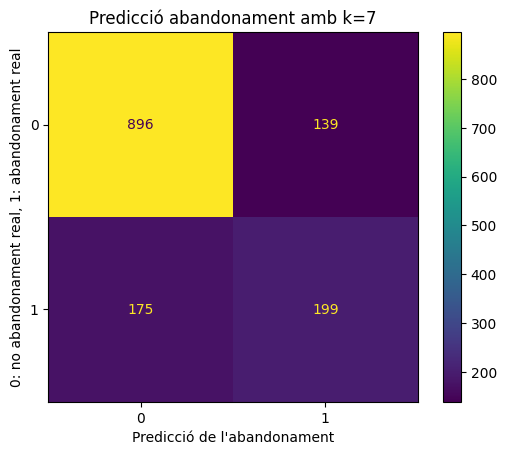

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred7)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.xlabel("Predicció de l'abandonament")
plt.ylabel('0: no abandonament real, 1: abandonament real')
plt.title('Predicció abandonament amb k=7')

*Una matriu de confusió com l'anterior, en el nostre cas, el que ens mostra és:*
- *A dalt a l'esquerra, els que el model predeix que no abandonen que realment no ho fan.*
- *A dalt a la dreta, els que el model predeix que abandonen i que realment no ho fan.*
- *A baix a l'esquerra, els que el model predeix que no abandonen i que realment sí que abandonen.*
- *I a baix a la dreta, els que el model predeix que abandonen i que realment ho fan.*

Fem un 'for' per anar variant el valor de la 'k' a veure si es pot millorar la exactitud:

In [10]:
# Fixem la llavor per a qualsevol procés aleatori (split, etc.), com ja s'ha explicat anteriorment
np.random.seed(7)
random.seed(7)

# Valors de k (nombre de "neighbors" que es consideren per client) per la iteració, gafant només valors de 'k' senars ja que els parells poden portar problemes amb aquest tipus de model predictiu al tractar-se d'una anàlisi qualitativa (els clients abandonen o no ho fan).
neighbors = np.arange(1,100,2)

# 'test_accuracy' servirà per anar emmagatzemant els diferents valors d'exactitud obtinguts
exactitud_test = np.empty(len(neighbors))

# Iterem pels diferents valors de k
for i, k in enumerate(neighbors):
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=1, algorithm="brute")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    exactitud = round(model.score(X_test,y_test)*100, 2)
    exactitud_test[i] = exactitud

# Representem gràficament l'exactitud que s'obté depenent del valor de 'k' utilitzat
#plt.plot(neighbors, exactitud_test1)
#plt.title('Exactitud k-nearest neighbor prediction: totes les variables')
#plt.xlabel('Nombre de neighbors')
#plt.ylabel('Exactitud')
#plt.show()

Repetim el mateix però ara fem una selecció de les columnes de dades que volem utilitzar per fer la predicció, basant-nos en les variables que els coeficients de la Regressió Logística (notebook 'LogisticRegression') indiquen que més afecten en l'abandonament. Ara bé, cada vegada que fem una nova selecció de variables, tot i que d'entrada ens basarem amb els coeficients, si veiem que hi ha quelcom que no encaixa amb els resultats que hem obtingut al llarg del projecte, si es considera farem alguna modificació. Cal comentar, però, que la majoria de coeficients concorden amb els resultats obtinguts per nosaltres.

Primer fem un nou conjunt de dades agafant d'entrada les variables amb un coeficient d'ordre 10e-2 o més gran (descartem els d'ordre 10e-3).

Per evitar problemes posteriorment, partim dels fitxers X_train, X_test, y_train i y_test obtinguts al principi amb totes les variables, i els hi fem les modificacions corresponents:

In [11]:
X_train1 = X_train.copy()
X_train1.drop('DeviceProtection',axis=1,inplace=True)
X_train1.drop('gender',axis=1,inplace=True)
X_train1.drop('Partner_Yes',axis=1,inplace=True)
X_train1.drop('PaymentMethod_Mailed check',axis=1,inplace=True)

X_test1 = X_test.copy()
X_test1.drop('DeviceProtection',axis=1,inplace=True)
X_test1.drop('gender',axis=1,inplace=True)
X_test1.drop('Partner_Yes',axis=1,inplace=True)
X_test1.drop('PaymentMethod_Mailed check',axis=1,inplace=True)

# 'y_train' i 'y_test' seran els mateixos en tots els casos, ja que només són els valors del 'Churn', que és la variable a predir

Fem el model predictiu per aquest nou Dataframe i comparem resultats:

In [12]:
# Fixem la llavor per a qualsevol procés aleatori (split, etc.), com ja s'ha explicat anteriorment
np.random.seed(7)
random.seed(7)

# Valors de k (nombre de veïns que es consideren per client) per la iteració, agafant només valors de 'k' senars ja que els parells poden portar problemes amb aquest tipus de model predictiu al tractar-se d'una anàlisi qualitativa.
neighbors1 = np.arange(1,100,2)

# 'test_accuracy' servirà per anar emmagatzemant els diferents valors d'exactitud obtinguts
exactitud_test1 = np.empty(len(neighbors1))

# Iterem pels diferents valors de k
for i, k in enumerate(neighbors1):
    model1 = KNeighborsClassifier(n_neighbors=k, n_jobs=1, algorithm="brute")
    model1.fit(X_train1, y_train)
    y_pred1 = model1.predict(X_test1)
    exactitud1 = round(model1.score(X_test1,y_test)*100, 2)
    exactitud_test1[i] = exactitud1

# Representem gràficament l'exactitud que s'obté depenent del valor de 'k' utilitzat
#plt.plot(neighbors, exactitud_test)
#plt.title('Exactitud k-nearest neighbor prediction')
#plt.xlabel('Nombre de neighbors')
#plt.ylabel('Exactitud')
#plt.show()

Fem el mateix però ara ens quedem només amb les variables que tenen un coeficient en valor absolut més gran o igual a 0.3:

In [13]:
X_train2 = X_train.copy()
X_train2.drop('DeviceProtection',axis=1,inplace=True)
X_train2.drop('gender',axis=1,inplace=True)
X_train2.drop('Partner_Yes',axis=1,inplace=True)
X_train2.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_train2.drop('SeniorCitizen',axis=1,inplace=True)
X_train2.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_train2.drop('PaperlessBilling',axis=1,inplace=True)
X_train2.drop('OnlineBackup',axis=1,inplace=True)
X_train2.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_train2.drop('Dependents',axis=1,inplace=True)
X_train2.drop('PhoneService',axis=1,inplace=True)
X_train2.drop('Partner_nan',axis=1,inplace=True)

X_test2 = X_test.copy()
X_test2.drop('DeviceProtection',axis=1,inplace=True)
X_test2.drop('gender',axis=1,inplace=True)
X_test2.drop('Partner_Yes',axis=1,inplace=True)
X_test2.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_test2.drop('SeniorCitizen',axis=1,inplace=True)
X_test2.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_test2.drop('PaperlessBilling',axis=1,inplace=True)
X_test2.drop('OnlineBackup',axis=1,inplace=True)
X_test2.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_test2.drop('Dependents',axis=1,inplace=True)
X_test2.drop('PhoneService',axis=1,inplace=True)
X_test2.drop('Partner_nan',axis=1,inplace=True)

In [14]:
# Fixem la llavor per a qualsevol procés aleatori (split, etc.), com ja s'ha explicat anteriorment
np.random.seed(7)
random.seed(7)

# Valors de k (nombre de veïns que es consideren per client) per la iteració, agafant només valors de 'k' senars ja que els parells poden portar problemes amb aquest tipus de model predictiu al tractar-se d'una anàlisi qualitativa.
neighbors2 = np.arange(1,100,2)

# 'test_accuracy' servirà per anar emmagatzemant els diferents valors d'exactitud obtinguts
exactitud_test2 = np.empty(len(neighbors2))

# Iterem pels diferents valors de k
for i, k in enumerate(neighbors2):
    model2 = KNeighborsClassifier(n_neighbors=k, n_jobs=1, algorithm="brute")
    model2.fit(X_train2, y_train)
    y_pred2 = model2.predict(X_test2)
    exactitud2 = round(model2.score(X_test2,y_test)*100, 2)
    exactitud_test2[i] = exactitud2

# Representem gràficament l'exactitud que s'obté depenent del valor de 'k' utilitzat
#plt.plot(neighbors, exactitud_test)
#plt.title('Exactitud k-nearest neighbor prediction')
#plt.xlabel('Nombre de neighbors')
#plt.ylabel('Exactitud')
#plt.show()

Com que es veu que el percentatge d'exactitud augmenta més ara (tot i que aquí s'ha "amagat" el gràfic perquè ja apareix més endavant), provem amb un DataFrame amb les variables només que tinguin un coeficient més gran de 0.5 (més ja no perquè ens quedaríem amb masses poques variables, i durant tot l'estudi hem vist que no només 3 variables afecten a la taxa d'abandonament).

In [15]:
X_train3 = X_train.copy()
X_train3.drop('DeviceProtection',axis=1,inplace=True)
X_train3.drop('gender',axis=1,inplace=True)
X_train3.drop('Partner_Yes',axis=1,inplace=True)
X_train3.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_train3.drop('SeniorCitizen',axis=1,inplace=True)
X_train3.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_train3.drop('PaperlessBilling',axis=1,inplace=True)
X_train3.drop('OnlineBackup',axis=1,inplace=True)
X_train3.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_train3.drop('Dependents',axis=1,inplace=True)
X_train3.drop('PhoneService',axis=1,inplace=True)
X_train3.drop('Partner_nan',axis=1,inplace=True)
X_train3.drop('StreamingTV',axis=1,inplace=True)
X_train3.drop('PaymentMethod_Electronic check',axis=1,inplace=True)
X_train3.drop('MultipleLines_Yes',axis=1,inplace=True)
X_train3.drop('StreamingMovies',axis=1,inplace=True)
X_train3.drop('TechSupport',axis=1,inplace=True)
X_train3.drop('OnlineSecurity',axis=1,inplace=True)

X_test3 = X_test.copy()
X_test3.drop('DeviceProtection',axis=1,inplace=True)
X_test3.drop('gender',axis=1,inplace=True)
X_test3.drop('Partner_Yes',axis=1,inplace=True)
X_test3.drop('PaymentMethod_Mailed check',axis=1,inplace=True)
X_test3.drop('SeniorCitizen',axis=1,inplace=True)
X_test3.drop('MultipleLines_No phone service',axis=1,inplace=True)
X_test3.drop('PaperlessBilling',axis=1,inplace=True)
X_test3.drop('OnlineBackup',axis=1,inplace=True)
X_test3.drop('PaymentMethod_Credit card (automatic)',axis=1,inplace=True)
X_test3.drop('Dependents',axis=1,inplace=True)
X_test3.drop('PhoneService',axis=1,inplace=True)
X_test3.drop('Partner_nan',axis=1,inplace=True)
X_test3.drop('StreamingTV',axis=1,inplace=True)
X_test3.drop('PaymentMethod_Electronic check',axis=1,inplace=True)
X_test3.drop('MultipleLines_Yes',axis=1,inplace=True)
X_test3.drop('StreamingMovies',axis=1,inplace=True)
X_test3.drop('TechSupport',axis=1,inplace=True)
X_test3.drop('OnlineSecurity',axis=1,inplace=True)

In [16]:
# Fixem la llavor per a qualsevol procés aleatori (split, etc.), com ja s'ha explicat anteriorment
np.random.seed(7)
random.seed(7)

# Valors de k (nombre de veïns que es consideren per client) per la iteració, agafant només valors de 'k' senars ja que els parells poden portar problemes amb aquest tipus de model predictiu al tractar-se d'una anàlisi qualitativa.
neighbors3 = np.arange(1,100,2)

# 'test_accuracy' servirà per anar emmagatzemant els diferents valors d'exactitud obtinguts
exactitud_test3 = np.empty(len(neighbors3))

# Iterem pels diferents valors de k
for i, k in enumerate(neighbors3):
    model3 = KNeighborsClassifier(n_neighbors=k, n_jobs=1, algorithm="brute")
    model3.fit(X_train3, y_train)
    y_pred3 = model3.predict(X_test3)
    exactitud3 = round(model3.score(X_test3,y_test)*100, 2)
    exactitud_test3[i] = exactitud3

# Representem gràficament l'exactitud que s'obté depenent del valor de 'k' utilitzat
#plt.plot(neighbors, exactitud_test)
#plt.title('Exactitud k-nearest neighbor prediction')
#plt.xlabel('Nombre de neighbors')
#plt.ylabel('Exactitud')
#plt.show()

Representem gràficament l'exactitud segons el valor de 'k' utilitzat pels 4 conjunts de dades que hem utilitzat anant eliminant columnes de variables. A cada gràfic pel punt més alt d'exactitud s'hi assenyala el valor d'aquesta i també el valor de k corresponent (eixos iguals pels 4 gràfics, així es poden comparar bé els resultats obtinguts). Els gràfics següents han estat creats amb l'ajuda del ChatGPT:

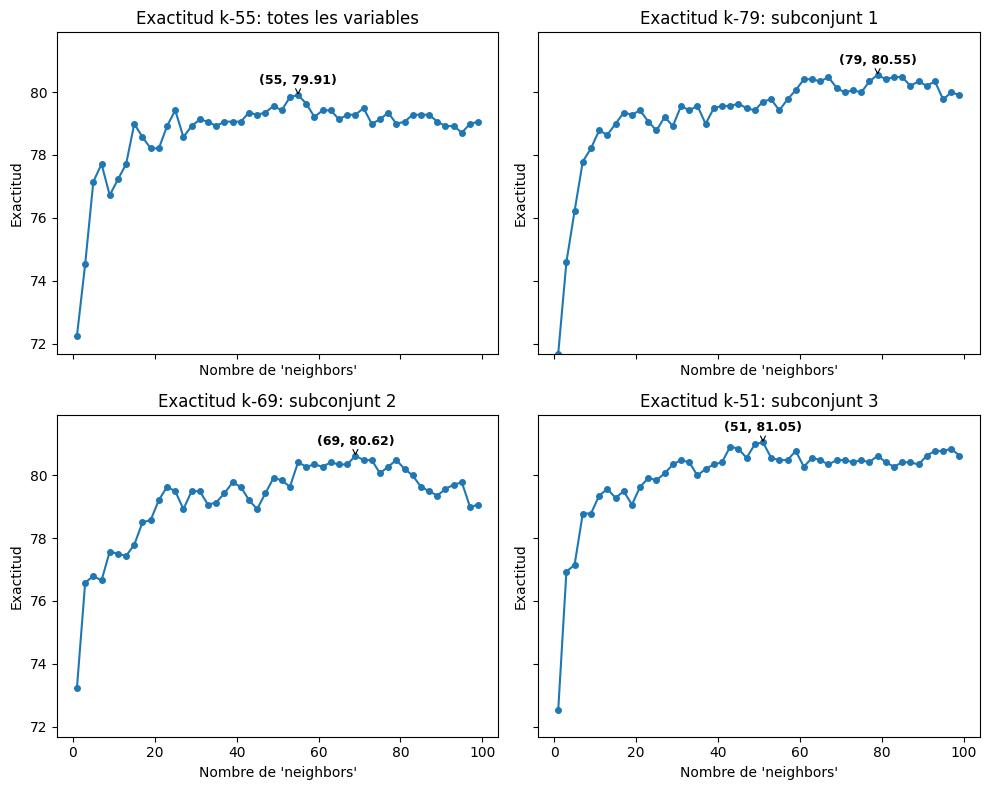

In [17]:
results = [
    ('totes les variables', exactitud_test),
    ('subconjunt 1', exactitud_test1),
    ('subconjunt 2', exactitud_test2),
    ('subconjunt 3', exactitud_test3),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (subtitle, acc) in zip(axes.ravel(), results):
    # fem servir markersize petit (per exemple 4)
    ax.plot(neighbors, acc, marker='o', markersize=4)
    
    # trobar el punt més alt
    max_idx = np.argmax(acc)
    max_x = neighbors[max_idx]
    max_y = acc[max_idx]
    
    # anotar tant l'X com l'Y just sobre aquest punt més alt
    ax.annotate(f'({max_x}, {max_y:.2f})',
                xy=(max_x, max_y),
                xytext=(0, 8),              # desplaçament vertical
                textcoords='offset points',
                ha='center', 
                fontsize=9,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=0.8))

    # càlcul del marge en l'eix y dels gràfics
    ymin, ymax = acc.min(), acc.max()
    dy = (ymax - ymin) * 0.1
    ax.set_ylim(ymin - dy, ymax + dy)
    
    ax.set_title(f'Exactitud k-{max_x}: {subtitle}')
    ax.set_xlabel("Nombre de 'neighbors'")
    ax.set_ylabel('Exactitud')

plt.tight_layout()
plt.show()

Veiem que per cap dels 4 gràfics el punt més alt és un pic puntual d'una sola 'k', sinó que més aviat sembla una tendència. Primer augmenta la exactitud molt ràpidament i llavors s'estableix a mesura que la 'k' segueix augmentant. En els gràfics de dalt a l'esquerra i de baix a la dreta sembla que hi hagi un pic però ho considerem vàlid ja que no és un pic ni molt exagerat ni d'un únic valor. I en el gràfic de baix a l'esquerra sobretot després d'aquesta exactitud màxima trobada veiem que aquesta torna a disminuir, segurament degut a que a partir de llavors els nombres de valors veïns que s'agafen ja són massa grans i els resultats no són representatius.

Veiem que a mesura que anem fent més petit el conjunt de variables que considerem per fer la predicció, millor exactitud té el model que obtenim. Per tant podem arribar a la conclusió de que els coeficients obtinguts a partir de la Regressió Logística (i que a més concorden bastant amb el que hem anat concloent al llarg del Projecte) semblen correctes ja que ens permeten obtenir exactituds millors. Ara bé, aquests valors d'exactitud no ho són tot per veure si els models són més o menys bons.

Representem els resultats també amb gràfics que ens permetin veure les matrius de confusió, per veure on estan els encerts i on hi podria haver algun problema amb els models. Per cada un dels conjunts de dades utilitzats representem la matriu de confusió per la 'k' que en cada un dels gràfics anteriors hem vist que ens dona una millor exactitud. El codi següent per obtenir els gràfics també ha estat creat amb l'ajuda del ChatGPT:

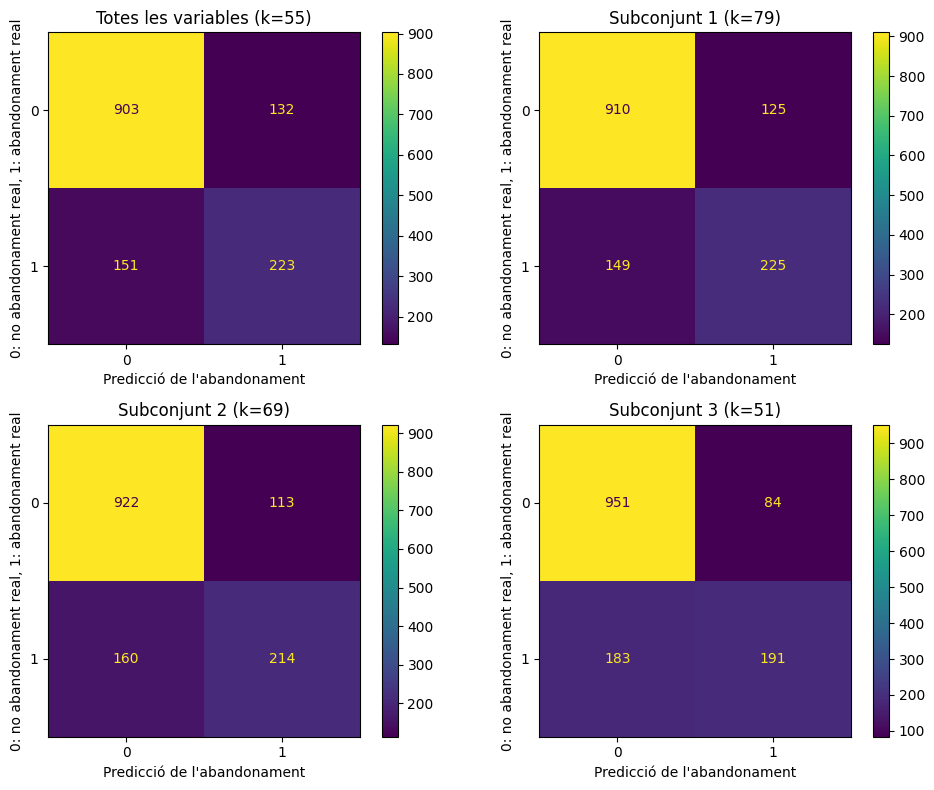

In [18]:
# Llista de tots els valors de k provats
neighbors = np.arange(1,100,2)

# Les quatre llistes d'exactitud per a cada subconjunt:
# exactitud_test, exactitud_test1, exactitud_test2, exactitud_test3

# Dades de train/test per a cada subconjunt:
datasets = [
    ('Totes les variables',
     X_train,     y_train,
     X_test,      y_test,
     exactitud_test),
    ('Subconjunt 1',
     X_train1, y_train,
     X_test1,  y_test,
     exactitud_test1),
    ('Subconjunt 2',
     X_train2, y_train,
     X_test2,  y_test,
     exactitud_test2),
    ('Subconjunt 3',
     X_train3, y_train,
     X_test3,  y_test,
     exactitud_test3),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (title, X_tr, y_tr, X_te, y_te, acc_list) in zip(axes.ravel(), datasets):
    # Troba el k amb exactitud màxima
    best_idx = np.argmax(acc_list)
    best_k = neighbors[best_idx]
    
    # Entrena el model amb el k òptim
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_tr, y_tr)
    
    # Predicció i matriu de confusió
    y_pred = knn.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)  # sense barra de color per a més claredat
    
    # Etiquetes i títol
    ax.set_xlabel("Predicció de l'abandonament")
    ax.set_ylabel('0: no abandonament real, 1: abandonament real')
    ax.set_title(f'{title} (k={best_k})')

plt.tight_layout()
plt.show()

D'aquí en podem treure diferents resultats interessants:
- Amb els gràfics d'exactitud en funció de 'k' hem vist que pel subconjunt de dades que li diem 3 s'obté la major exactitud. De fet a mesura que anem disminuint les variables del conjunt millor exactitud anem obtenint, tal com s'ha dit abans.
- Ara bé, com que el que ens interessa sobretot és predir els abandonaments, veiem que el subconjunt de dades que millor ho predeix és el que li diem "Subconjunt 1", i que el que ho predeix pitjor (tot i que és el que predeix millor els que no abandonen), és el propi Subconjunt 3. Amb el Subconjunt 2 i sobretot amb el de totes les variables (el de dalt a l'esquerra) s'obtenen resultats similars al Subconjunt 1, però ens quedem amb aquest últim perquè és el que predeix millor el que més ens interessa i a més la predicció pels que no abandonen tampoc és dolenta comparada amb els altres models.

Si considerem que la companyia, per tal de retenir clients que per característiques es predeix que podrien abandonar, els hi fa un preu més econòmic, anem a continuació a analitzar amb quin dels 4 models hi podria haver millors resultats tant econòmics com de taxa d'abandonament (que volem que disminueixi).

Cada model, dels clients que realment abandonen, una part predeix que no l'abandona; i dels que no abandonen una part predeix que sí. Si la companyia vol evitar abandonaments fent preus més econòmics pels clients que predeixen que poden abandonar, obtenim:
- MODEL AMB TOTES LES VARIABLES: a 132 clients se'ls hi oferiria un preu més econòmic, sense que fos necessari realment (per tant, la companyia perdria diners oferint preus més barats a clients que igualment no abandonarien); i a 151 dels que realment abandonen no se'ls hi oferiria el nou preu. Per tant, ens interessa que aquests dos números siguin com més petits millor i que alhora el nombre de clients que abandonen predits correctament (223 en aquest cas) sigui el més alt possible.
- SUBCONJUNT 1: a 125 se'ls hi oferiria el nou preu sense que fos necessari, a 149 dels que abandonen no, i a 225 dels que abandonen sí.
- SUBCONJUNT 2: a 113 se'ls hi oferiria el nou preu sense que fos necessari, a 160 dels que abandonen no, i a 214 dels que abandonen sí.
- SUBCONJUNT 3: a 84 se'ls hi oferiria el nou preu sense que fos necessari, a 183 dels que abandonen no, i a 191 dels que abandonen sí.

Dels 2 primers models (TOTES LES VARIABLES i SUBCONJUNT 1), està clar que el del SUBCONJUNT 1 és millor ja que tots els "números" que ens interessen són millors pel SUBCONJUNT 1, tot i que no per gaire.

Havent descartat el model amb totes les variables, amb la resta podem veure que si el que interessa és que es perdin el mínim de diners possible degut al preu econòmic, el SUBCONJUNT 3 és el millor, però alhora és el model que podria evitar menys abandonaments. En canvi el SUBCONJUNT 1 segurament faria que es perdessin més diners oferint una oferta a clients que no abandonarien, però evitaria més abandonaments. El SUBCONJUNT 2 ofereix uns resultats que estan entre els del subconjunt 1 i els del 3.

És a dir, aquí la companyia, si ho considerés oportú, hauria de buscar un preu rebaixat que fes que els beneficis (en mitjana) de tenir més clients que no abandonen, fossin més grans que les possibles pèrdues provocades per oferir una oferta no necessària a certs clients.

**Si la companyia trobés aquest equilibri, el més lògic sembla que seria quedar-nos amb el model de predicció "k-nearest_neighbor_prediction" que predeix millor els abandonaments, és a dir, el model que utilitza el SUBCONJUNT 1 de variables amb una k=79.**

Com a últim comentari de tot això, és evident que la companyia també hauria tenir en compte que si per evitar abandonaments decidissin per exemple, enviar correus o fer trucades als clients explicant motius pels que no haurien d'abandonar la companyia, això també podria comportar més abandonaments: alguns clients que s'ha predit que abandonen dels que realment no ho fan, es podrien cansar d'anar rebent correus o trucades de la pròpia companyia i acabar abandonant (tot i no tenir la intenció de fer-ho inicialment).

Per tant, per un costat queda clar que un model predictiu pot ajudar a la companyia a evitar abandonaments, sí. Ara bé, s'han d'avaluar correctament tots els riscos i problemes que poden aparèixer a causa dels mètodes utilitzats, ja que sinó, sense voler, intentant evitar abandonaments en pots provocar encara més.

Per acabar, obtenim els valors de 'recall' (proporció de positius reals que han estat correctament identificats), 'precision' (proporció de prediccions positives que realment són positives), i exactitud (percentatge d'encerts totals), del model seleccionat (SUBCONJUNT 1, k=79).

In [19]:
model_definitiu = KNeighborsClassifier(n_neighbors=79)
model_definitiu.fit(X_train1, y_train)

# Apliquem el model a les dades de test per llavors veure'n l'exactitud:
y_pred_def = model_definitiu.predict(X_test1)
exactitud_def = round(model_definitiu.score(X_test1, y_test)*100, 2)
print(f"EXACTITUD SUBCONJUNT 1, k=79: {exactitud_def} %") # percentatge d'encerts totals

EXACTITUD SUBCONJUNT 1, k=79: 80.55 %


In [20]:
from sklearn.metrics import classification_report

In [21]:
print(classification_report(y_test,y_pred_def))
# Recall: proporció de positius reals que han estat correctament identificats
# Precision: proporció de prediccions positives que realment són positives

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.64      0.60      0.62       374

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.75      1409
weighted avg       0.80      0.81      0.80      1409



El 'f1-score' (que en aquest cas és d'un 62% pels que abandonen, 87% pels que no), sembla la millor mesura per comparar diferents models predictius, ja que és la mitjana harmònica entre precision i recall, i mesura l’equilibri entre aquestes dues: f1-score=2(precision·recall)/(precision+recall)